In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

# Easy Problem

Here we consider a problem of the form $y''(x) = f(x,y(x))$.

* Learn the ODE:
$$- y^{''} = -2$$

* Subject to BCs:
$$ y(0) = 0$$
$$ y(1) = 0$$

* Has exact solution:

$$ y(x) = 1 + x(1 - x)$$

# Exact Solution

In [54]:
def exact_y(x):
    return 1 + x*(1-x)

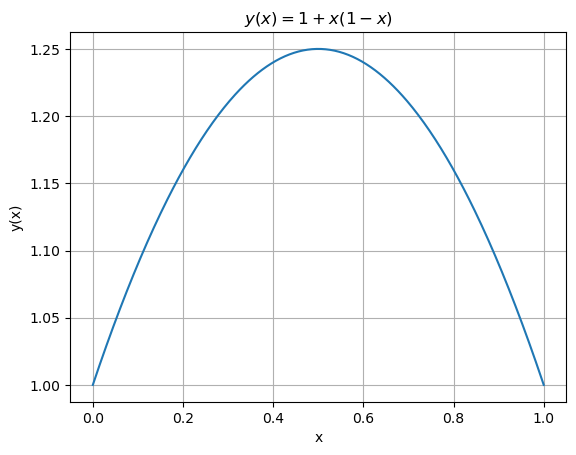

In [55]:
# Create x values
x = np.linspace(0, 1, 400)

# Evaluate function
y = exact_y(x)

# Plot
plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title(r"$y(x) = 1 + x(1-x)$")
plt.grid(True)
plt.show()

# Trainig Data

In [56]:
N_r = 100

# Interior points (exclude boundaries)
x_interior_np = np.linspace(0, 1, N_r + 2)[1:-1]   # remove 0 and 1
x_interior = torch.tensor(x_interior_np, dtype=torch.float32).view(-1,1)

x_interior.requires_grad_(True)

# Boundary points
x_boundary = torch.tensor([[0.0], [1.0]], dtype=torch.float32)
y_boundary = torch.tensor([[1.0], [1.0]], dtype=torch.float32)
y_boundary[1]

tensor([1.])

# Neural Network

Below we make a slight adjustment to our output $\hat{y} \to \tilde{y}$ in order to better incorporate the boundary conditions into the loss function. If we do not define this modification, the loss function slightly more cumbersome to work with. Note what we are doing now applies ODEs with $\textbf{Direchlt Boundry Conditions}$ (e.g $y(0) = y_0$ and $y(1) = y_1$).


* Original Loss function: where $\gamma$ is to be chosen (difficult):

$$ \mathcal{L}(x ; W, b) = \sum_{i = 1}^{N-1} (\hat{y}(x_i) - f(x_i, \hat{y}(x_i))^2 + \gamma (\hat{y}(0) - y_0)^2 + \gamma (\hat{y}(1) - y_1)^2 $$

*  We now introduce an alternate approach where we define $\tilde{y}$:

$$ \tilde{y} = \hat{y}(x) + (1 - x)(\hat{y}(0) - y_0) + x(\hat{y}(1) - y_1))$$

*  This approach automatically satisfies the BCs, We therfore define the new Loss function as:

$$ \bar{\mathcal{L}}(x ; W, b) = \sum_{i = 1}^{N-1} (\tilde{y}(x_i) - f(x_i, \tilde{y}(x_i))^2 $$


In [57]:
class SimpleNetwork(nn.Module):
    def __init__(self, x_boundary, y_boundary):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )
        # store as buffers so they move with model.to(device)
        self.register_buffer("x0", x_boundary[0:1])  # shape (1,1)
        self.register_buffer("x1", x_boundary[1:2])
        self.register_buffer("y0", y_boundary[0:1])
        self.register_buffer("y1", y_boundary[1:2])

    def forward(self, x):
        y_hat = self.net(x)
        y_hat0 = self.net(self.x0)  
        y_hat1 = self.net(self.x1)
        
        y_tilde = y_hat + (1 - x) * (self.y0 - y_hat0) + x * (self.y1 - y_hat1)
        return y_tilde

In [58]:
torch.manual_seed(0)
model = SimpleNetwork(x_boundary = x_boundary, y_boundary = y_boundary)

# Compute 2nd derivative

In [59]:
def second_derivative(y, x):
    dy_dx = torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

    d2y_dx2 = torch.autograd.grad(
        dy_dx, x,
        grad_outputs=torch.ones_like(dy_dx),
        create_graph=True
    )[0]

    return d2y_dx2

# Train Model

In [60]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

epoch = 200
losses = []
for i in range(epoch):
    y_pred = model(x_interior)
    y_xx = second_derivative(y_pred, x_interior)
    residual = y_xx + 2.0

    loss = torch.sum(residual**2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

    # print every 10 epochs
    if i % 10 == 0:
        print(f'Epoch: {i} and loss: {loss}')

Epoch: 0 and loss: 388.88812255859375
Epoch: 10 and loss: 352.4783935546875
Epoch: 20 and loss: 316.1628112792969
Epoch: 30 and loss: 278.8813781738281
Epoch: 40 and loss: 239.53662109375
Epoch: 50 and loss: 197.69345092773438
Epoch: 60 and loss: 154.0936279296875
Epoch: 70 and loss: 110.95625305175781
Epoch: 80 and loss: 71.75291442871094
Epoch: 90 and loss: 40.44172668457031
Epoch: 100 and loss: 19.77715301513672
Epoch: 110 and loss: 9.24431324005127
Epoch: 120 and loss: 5.081846237182617
Epoch: 130 and loss: 3.470346212387085
Epoch: 140 and loss: 2.68485689163208
Epoch: 150 and loss: 2.209716320037842
Epoch: 160 and loss: 1.8641411066055298
Epoch: 170 and loss: 1.5969802141189575
Epoch: 180 and loss: 1.3824902772903442
Epoch: 190 and loss: 1.2029892206192017


# Plot 

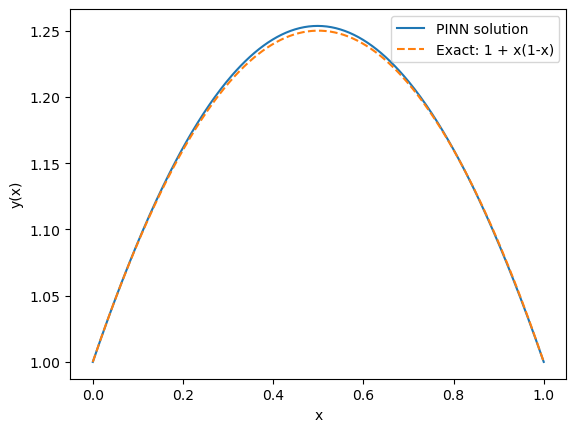

In [61]:
# Create fine grid for plotting
x_plot = torch.linspace(0, 1, 400).view(-1, 1)

model.eval()
with torch.no_grad():
    y_plot = model(x_plot)

# Convert to numpy
x_np = x_plot.numpy().ravel()
y_pinn = y_plot.numpy().ravel()

# Exact solution: y = 1 + x(1-x)
y_exact = 1 + x_np*(1 - x_np)

# Plot
plt.figure()
plt.plot(x_np, y_pinn, label="PINN solution")
plt.plot(x_np, y_exact, "--", label="Exact: 1 + x(1-x)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.show()

# Error Analysis

# Robin Boundary Conditions Example

From here on we will slightly change our notation to a more general form (helps when studying more complicated ODES). Want to solve $g(x, y(x), y'(x), y''(x)) = 0$.

* Learn the ODE:
$$y^{''} + y = \sin(\pi x)$$

* Subject to BCs:
$$ y'(0) + y(0) = 0$$
$$ y'(1) + y(1) = 1$$

* Has exact solution:

$$ y(x)=
\frac{\pi\big(1+\sin 1+\cos 1\big)-(\pi^2-1)}
{2\sin 1\,(\pi^2-1)}\,\cos x
+
\frac{(\pi^2-1)+\pi\big(\sin 1-\cos 1-1\big)}
{2\sin 1\,(\pi^2-1)}\,\sin x - \frac{\sin(\pi x)}{\pi^2-1} $$

# Exact Solution

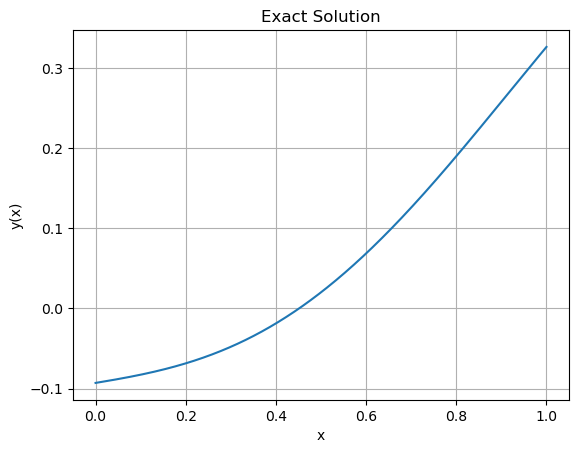

In [62]:
# Define the exact solution
def y(x):
    numerator1 = np.pi*(1 + np.sin(1) + np.cos(1)) - (np.pi**2 - 1)
    numerator2 = (np.pi**2 - 1) + np.pi*(np.sin(1) - np.cos(1) - 1)
    denominator = 2*np.sin(1)*(np.pi**2 - 1)

    term1 = (numerator1 / denominator) * np.cos(x)
    term2 = (numerator2 / denominator) * np.sin(x)
    term3 = - np.sin(np.pi * x) / (np.pi**2 - 1)

    return term1 + term2 + term3

# Domain
x_vals = np.linspace(0, 1, 500)
y_vals = y(x_vals)

# Plot
plt.figure()
plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Exact Solution")
plt.grid(True)
plt.show()

In [63]:
# Training Data
N_r = 100

# Interior points (exclude boundaries)
x_interior_np = np.linspace(0, 1, N_r + 2)[1:-1]   # remove 0 and 1
x_interior = torch.tensor(x_interior_np, dtype=torch.float32).view(-1,1)

x_interior.requires_grad_(True)

# Boundary points
alpha1 = torch.tensor([[1.0]])
beta1  = torch.tensor([[1.0]])
gamma1 = torch.tensor([[0.0]])
alpha2 = torch.tensor([[1.0]])
beta2  = torch.tensor([[1.0]])
gamma2 = torch.tensor([[1.0]])

a = torch.tensor([[0.0]], requires_grad=True)
b = torch.tensor([[1.0]], requires_grad=True)


# Neural Network

We now adapt our previous concept of $\hat{y} \to \tilde{y}$ for more general $\textbf{Robin Boundry Conditions}$. Now we have boundary conditions of the form:

$$\alpha_1 y(a) + \beta_1 y'(a) = \gamma_1$$
$$\alpha_2 y(b) + \beta_2 y'(b) = \gamma_2$$


* Original Loss function: where $\gamma$ is to be chosen (difficult) ($\gamma$ and $\gamma_1$ , $\gamma_2$ not related):

$$ \mathcal{L}(x ; W, b) = \sum_{i = 1}^{N-1} (g(x_i, \hat{y}(x_i), \hat{y}'(x_i), \hat{y}''(x_i)))^2 + \gamma (\alpha_1 \hat{y}(a) + \beta_1 \hat{y}'(a) - \gamma_1)^2 + \gamma (\alpha_2 \hat{y}(b) + \beta_2 \hat{y}'(b) - \gamma_2)^2 $$

*  We now introduce an alternate approach where we define $\tilde{y}$, (define $d = \alpha_1 \alpha_2 (b-a) + \alpha_1 \beta_2 - \alpha_2 \beta_1$:

$$ \tilde{y} = \hat{y}(x) + \frac{\alpha_2 b + \beta_2 - \alpha_2 x}{d}(\gamma_1 - (\alpha_1\hat{y}(a) + \beta_1 \hat{y}'(a))) +  \frac{\alpha_1 x - (\alpha_1a + \beta_1)}{d}(\gamma_2 - (\alpha_2\hat{y}(b) + \beta_2 \hat{y}'(b) ))$$

*  This approach automatically satisfies the BCs, We therfore define the new Loss function as:

$$ \bar{\mathcal{L}}(x ; W, b) = \sum_{i = 1}^{N-1} (g(x_i, \tilde{y}(x_i), \tilde{y}'(x_i), \tilde{y}''(x_i)))^2 $$


In [64]:
class BasicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, x):
        return self.net(x)

# Derivative Helpers
def d_dx(y, x):
    (dy,) = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)
    return dy

def d2_dx2(y, x):
    dy = d_dx(y, x)
    dyy = d_dx(dy, x)
    return dyy

# y tilda transformation
def robin_transform(model, x, a, b, alpha1, beta1, gamma1, alpha2, beta2, gamma2):
     y_hat_x = model(x)

     y_hat_a = model(a)
     y_hat_b = model(b)
     dy_hat_a = d_dx(y_hat_a, a)
     dy_hat_b = d_dx(y_hat_b, b)

     # residuals of Robin BCs for y_hat
     r1 = gamma1 - (alpha1 * y_hat_a + beta1 * dy_hat_a)
     r2 = gamma2 - (alpha2 * y_hat_b + beta2 * dy_hat_b)
     d = alpha1 * alpha2 * (b - a) + alpha1 * beta2 - alpha2 * beta1
     A = (alpha2 * b + beta2 - alpha2 * x) / d
     B = (alpha1 * x - (alpha1 * a + beta1)) / d

     # y_tilde
     y_tilde = y_hat_x + A * r1 + B * r2
     return y_tilde

def forcing(x):
    return torch.sin(np.pi * x)

# Train Model

In [65]:
torch.manual_seed(0)
robin_model = BasicNetwork()

In [70]:
optimizer = torch.optim.Adam(robin_model.parameters(), lr=1e-3)

epoch = 200
losses = []
for i in range(epoch):
    y_tilde = robin_transform(robin_model, x_interior, a, b,
                              alpha1, beta1, gamma1,
                              alpha2, beta2, gamma2)
    
    # 2) residual: y'' + y - sin(pi x)
    y_xx_tilde = d2_dx2(y_tilde, x_interior)
    r = y_xx_tilde + y_tilde - forcing(x_interior)

    loss = torch.mean(r**2)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

    # print every 10 epochs
    if i % 10 == 0:
        print(f'Epoch: {i} and loss: {loss}')

Epoch: 0 and loss: 0.0001662324502831325
Epoch: 10 and loss: 0.0013146221172064543
Epoch: 20 and loss: 0.00048567671910859644
Epoch: 30 and loss: 0.0001689840864855796
Epoch: 40 and loss: 0.00016385097114834934
Epoch: 50 and loss: 0.00016033448628149927
Epoch: 60 and loss: 0.00015366570733021945
Epoch: 70 and loss: 0.0001493384625064209
Epoch: 80 and loss: 0.0001462161890231073
Epoch: 90 and loss: 0.00014243517944123596
Epoch: 100 and loss: 0.00013825450150761753
Epoch: 110 and loss: 0.00013436983863357455
Epoch: 120 and loss: 0.00013036205200478435
Epoch: 130 and loss: 0.0001263364974875003
Epoch: 140 and loss: 0.0001222698629135266
Epoch: 150 and loss: 0.00011819101200671867
Epoch: 160 and loss: 0.00011410674051148817
Epoch: 170 and loss: 0.00011002996325260028
Epoch: 180 and loss: 0.00010597331129247323
Epoch: 190 and loss: 0.00010194622882409021


# Plot

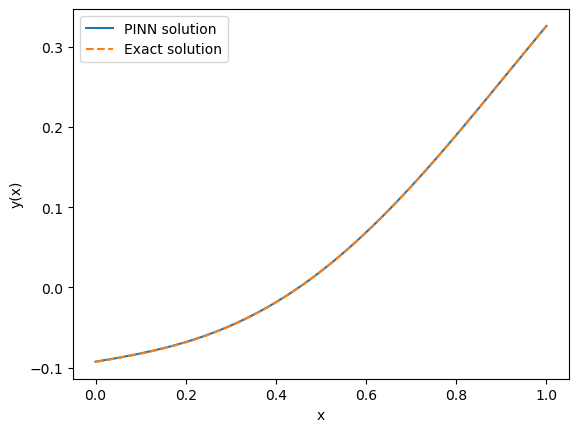

In [71]:
# Create fine grid for plotting
x_plot = torch.linspace(0, 1, 400).view(-1, 1)

robin_model.eval()

y_tilde_plot = robin_transform(robin_model, x_plot, a, b,
                               alpha1, beta1, gamma1,
                               alpha2, beta2, gamma2)

# Convert to numpy
x_np = x_plot.numpy().ravel()
y_pinn = y_tilde_plot.detach().cpu().numpy().ravel()

# Exact solution: y = 1 + x(1-x)
y_exact = y(x_np)

# Plot
plt.figure()
plt.plot(x_np, y_pinn, label="PINN solution")
plt.plot(x_np, y_exact, "--", label="Exact solution")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.show()

## Questions:
Extention to a nonlinear ODE (issue: hard to find exact solution for comparison)

How best compair everything? (e.g Number of grid points / epochs) One long line of code?

New Notebook with one massive function that can be varied easily.